In [1493]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import metrics

In [1494]:
read_file = pd.read_excel("CollectedData.xlsx", sheet_name="Sheet2")
read_file.to_csv ("CollectedData.csv", index = None, header=True)

In [1614]:
df = pd.read_csv("CollectedData.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12565 entries, 0 to 12564
Data columns (total 80 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   8                   12561 non-null  float64
 1   1                   12562 non-null  float64
 2   Unnamed: 2          9650 non-null   float64
 3   0                   12340 non-null  float64
 4   1993                11213 non-null  float64
 5   146                 12549 non-null  float64
 6   Unnamed: 6          9746 non-null   float64
 7   2                   12510 non-null  float64
 8   1.1                 12514 non-null  float64
 9   Unnamed: 9          3354 non-null   float64
 10  Unnamed: 10         11778 non-null  float64
 11  Unnamed: 11         4638 non-null   float64
 12  Unnamed: 12         3371 non-null   float64
 13  Unnamed: 13         5623 non-null   float64
 14  Unnamed: 14         4909 non-null   float64
 15  Unnamed: 15         4866 non-null   float64
 16  Unna

In [1615]:
df.describe()

,8,1,Unnamed: 2,0,1993,146,Unnamed: 6,2,1.1,Unnamed: 9,...,Unnamed: 70,15.3,7.8,11.55,58,100,79,15.4,8.1,11.7
count,12561.000000,12562.000000,9650.000000,12340.000000,11213.000000,12549.000000,9746.000000,12510.000000,12514.000000,3354.000000,...,3060.000000,12546.000000,11197.000000,11197.000000,12546.000000,12546.000000,12546.000000,12545.000000,12545.000000,12545.000000
mean,6.349647,218.228069,308.637202,17.738250,1990.376260,154.491234,869.834524,0.100584,1.857599,1.831544,...,1.683333,21.635212,13.406287,17.175087,56.622620,72.957013,61.098939,18.743268,12.320343,15.533866
std,5.453443,375.301009,680.115105,64.558478,4.863711,123.037790,609.240369,1.102012,0.414922,0.374326,...,1.273379,11.239960,10.228617,10.665415,18.121491,28.753290,24.704364,12.801067,10.883264,11.622522
min,1.000000,0.000000,0.000000,-1.000000,1982.000000,-3.000000,0.090278,-3.000000,1.000000,1.000000,...,1.000000,-22.600000,-27.200000,-24.900000,6.100000,-2.200000,0.000000,-22.700000,-27.300000,-25.000000
25%,2.000000,15.000000,26.000000,0.000000,1987.000000,23.000000,15.000000,-0.700000,2.000000,2.000000,...,1.000000,15.555556,7.260000,11.350000,45.100000,68.700000,53.769937,9.400000,4.100000,6.750000
50%,4.000000,59.000000,35.000000,1.000000,1992.000000,156.000000,1055.000000,0.000000,2.000000,2.000000,...,1.000000,25.000000,13.600000,18.200000,59.000000,83.000000,68.795799,21.200000,12.300000,16.350000
75%,10.000000,187.000000,45.000000,1.000000,1994.000000,242.000000,1410.750000,1.000000,2.000000,2.000000,...,2.000000,30.400000,22.200000,26.600000,67.000000,91.588515,76.950000,30.000000,22.200000,25.400000
max,61.000000,2031.000000,1996.000000,292.000000,1997.000000,365.000000,1930.000000,3.000000,3.000000,2.000000,...,6.000000,41.700000,28.900000,32.350000,100.000000,123.789573,100.350000,37.800000,33.200000,34.500000


In [1616]:
df=df.rename(columns={df.columns[2]: 'Age', df.columns[21]: 'Clo', df.columns[18]: 'Met', df.columns[25]: 'Dewpt', df.columns[26]: 'PlaneRadTemp', df.columns[36]: 'Ta', df.columns[37]: 'Tmrt', df.columns[39]: 'Vel', df.columns[41]: 'AirTurb', df.columns[42]: 'Pa', df.columns[43]: 'Rh', df.columns[73]: 'TaOutdoor', df.columns[76]: 'RhOutdoor', df.columns[7]: 'AMV', df.columns[48]: 'PMV'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12565 entries, 0 to 12564
Data columns (total 80 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   8                   12561 non-null  float64
 1   1                   12562 non-null  float64
 2   Age                 9650 non-null   float64
 3   0                   12340 non-null  float64
 4   1993                11213 non-null  float64
 5   146                 12549 non-null  float64
 6   Unnamed: 6          9746 non-null   float64
 7   AMV                 12510 non-null  float64
 8   1.1                 12514 non-null  float64
 9   Unnamed: 9          3354 non-null   float64
 10  Unnamed: 10         11778 non-null  float64
 11  Unnamed: 11         4638 non-null   float64
 12  Unnamed: 12         3371 non-null   float64
 13  Unnamed: 13         5623 non-null   float64
 14  Unnamed: 14         4909 non-null   float64
 15  Unnamed: 15         4866 non-null   float64
 16  Unna

In [1617]:
df= df[['Age','AMV','Met','Clo','Dewpt','PlaneRadTemp','Ta','Tmrt','Vel','AirTurb','Pa','Rh','PMV','TaOutdoor','RhOutdoor']]
df= df.sort_values(['Age','AMV','Met','Clo','Dewpt','PlaneRadTemp','Ta','Tmrt','Vel','AirTurb','Pa','Rh','PMV','TaOutdoor','RhOutdoor'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12565 entries, 542 to 6303
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           9650 non-null   float64
 1   AMV           12510 non-null  float64
 2   Met           10678 non-null  float64
 3   Clo           11159 non-null  float64
 4   Dewpt         9014 non-null   float64
 5   PlaneRadTemp  5544 non-null   float64
 6   Ta            12545 non-null  float64
 7   Tmrt          8864 non-null   float64
 8   Vel           8865 non-null   float64
 9   AirTurb       6965 non-null   float64
 10  Pa            7910 non-null   float64
 11  Rh            12530 non-null  float64
 12  PMV           11869 non-null  float64
 13  TaOutdoor     11197 non-null  float64
 14  RhOutdoor     12546 non-null  float64
dtypes: float64(15)
memory usage: 1.5 MB


# PART A 
# Question 1

In [1618]:
df.min()

Age              0.000
AMV             -3.000
Met              0.100
Clo              0.150
Dewpt           -1.953
PlaneRadTemp    -7.420
Ta              15.960
Tmrt            16.610
Vel              0.000
AirTurb          0.000
Pa               0.000
Rh               7.400
PMV             -4.170
TaOutdoor      -24.900
RhOutdoor        0.000
dtype: float64

In [1619]:
df.max()

Age             1996.00000
AMV                3.00000
Met                4.50000
Clo                2.13000
Dewpt             26.89675
PlaneRadTemp      11.70000
Ta                31.00000
Tmrt              37.44500
Vel                1.88000
AirTurb          102.45000
Pa                27.70000
Rh                79.30000
PMV                2.50000
TaOutdoor         32.35000
RhOutdoor        100.35000
dtype: float64

In [1620]:
df.mode()

,Age,AMV,Met,Clo,Dewpt,PlaneRadTemp,Ta,Tmrt,Vel,AirTurb,Pa,Rh,PMV,TaOutdoor,RhOutdoor
0,24.0,0.0,1.0,0.77,17.4,0.3,23.2,22.5,0.1,0.5,2.1,64.0,0.1,27.555556,0.0


In [1621]:
df.mean()

Age             308.637202
AMV               0.100584
Met               1.065907
Clo               0.778503
Dewpt            13.621447
PlaneRadTemp      0.217785
Ta               23.179187
Tmrt             23.450693
Vel               0.112445
AirTurb          18.265870
Pa                5.123996
Rh               42.528507
PMV              -0.073711
TaOutdoor        17.175087
RhOutdoor        61.098939
dtype: float64

In [1622]:
df.median()

Age             35.000000
AMV              0.000000
Met              1.100000
Clo              0.751700
Dewpt           14.100000
PlaneRadTemp     0.200000
Ta              23.136667
Tmrt            23.359219
Vel              0.100000
AirTurb          0.500000
Pa               1.550667
Rh              43.276815
PMV             -0.030000
TaOutdoor       18.200000
RhOutdoor       68.795799
dtype: float64

In [1623]:
df.var()

Age             462556.556104
AMV                  1.214430
Met                  0.183939
Clo                  0.049284
Dewpt               34.845928
PlaneRadTemp         1.084022
Ta                   2.053443
Tmrt                 2.257475
Vel                  0.006248
AirTurb            627.057129
Pa                  66.522562
Rh                 226.848017
PMV                  0.289471
TaOutdoor          113.751067
RhOutdoor          610.305583
dtype: float64

In [1624]:
df.std()

Age             680.115105
AMV               1.102012
Met               0.428882
Clo               0.221999
Dewpt             5.903044
PlaneRadTemp      1.041164
Ta                1.432984
Tmrt              1.502489
Vel               0.079044
AirTurb          25.041109
Pa                8.156136
Rh               15.061475
PMV               0.538025
TaOutdoor        10.665415
RhOutdoor        24.704364
dtype: float64

# Question 2

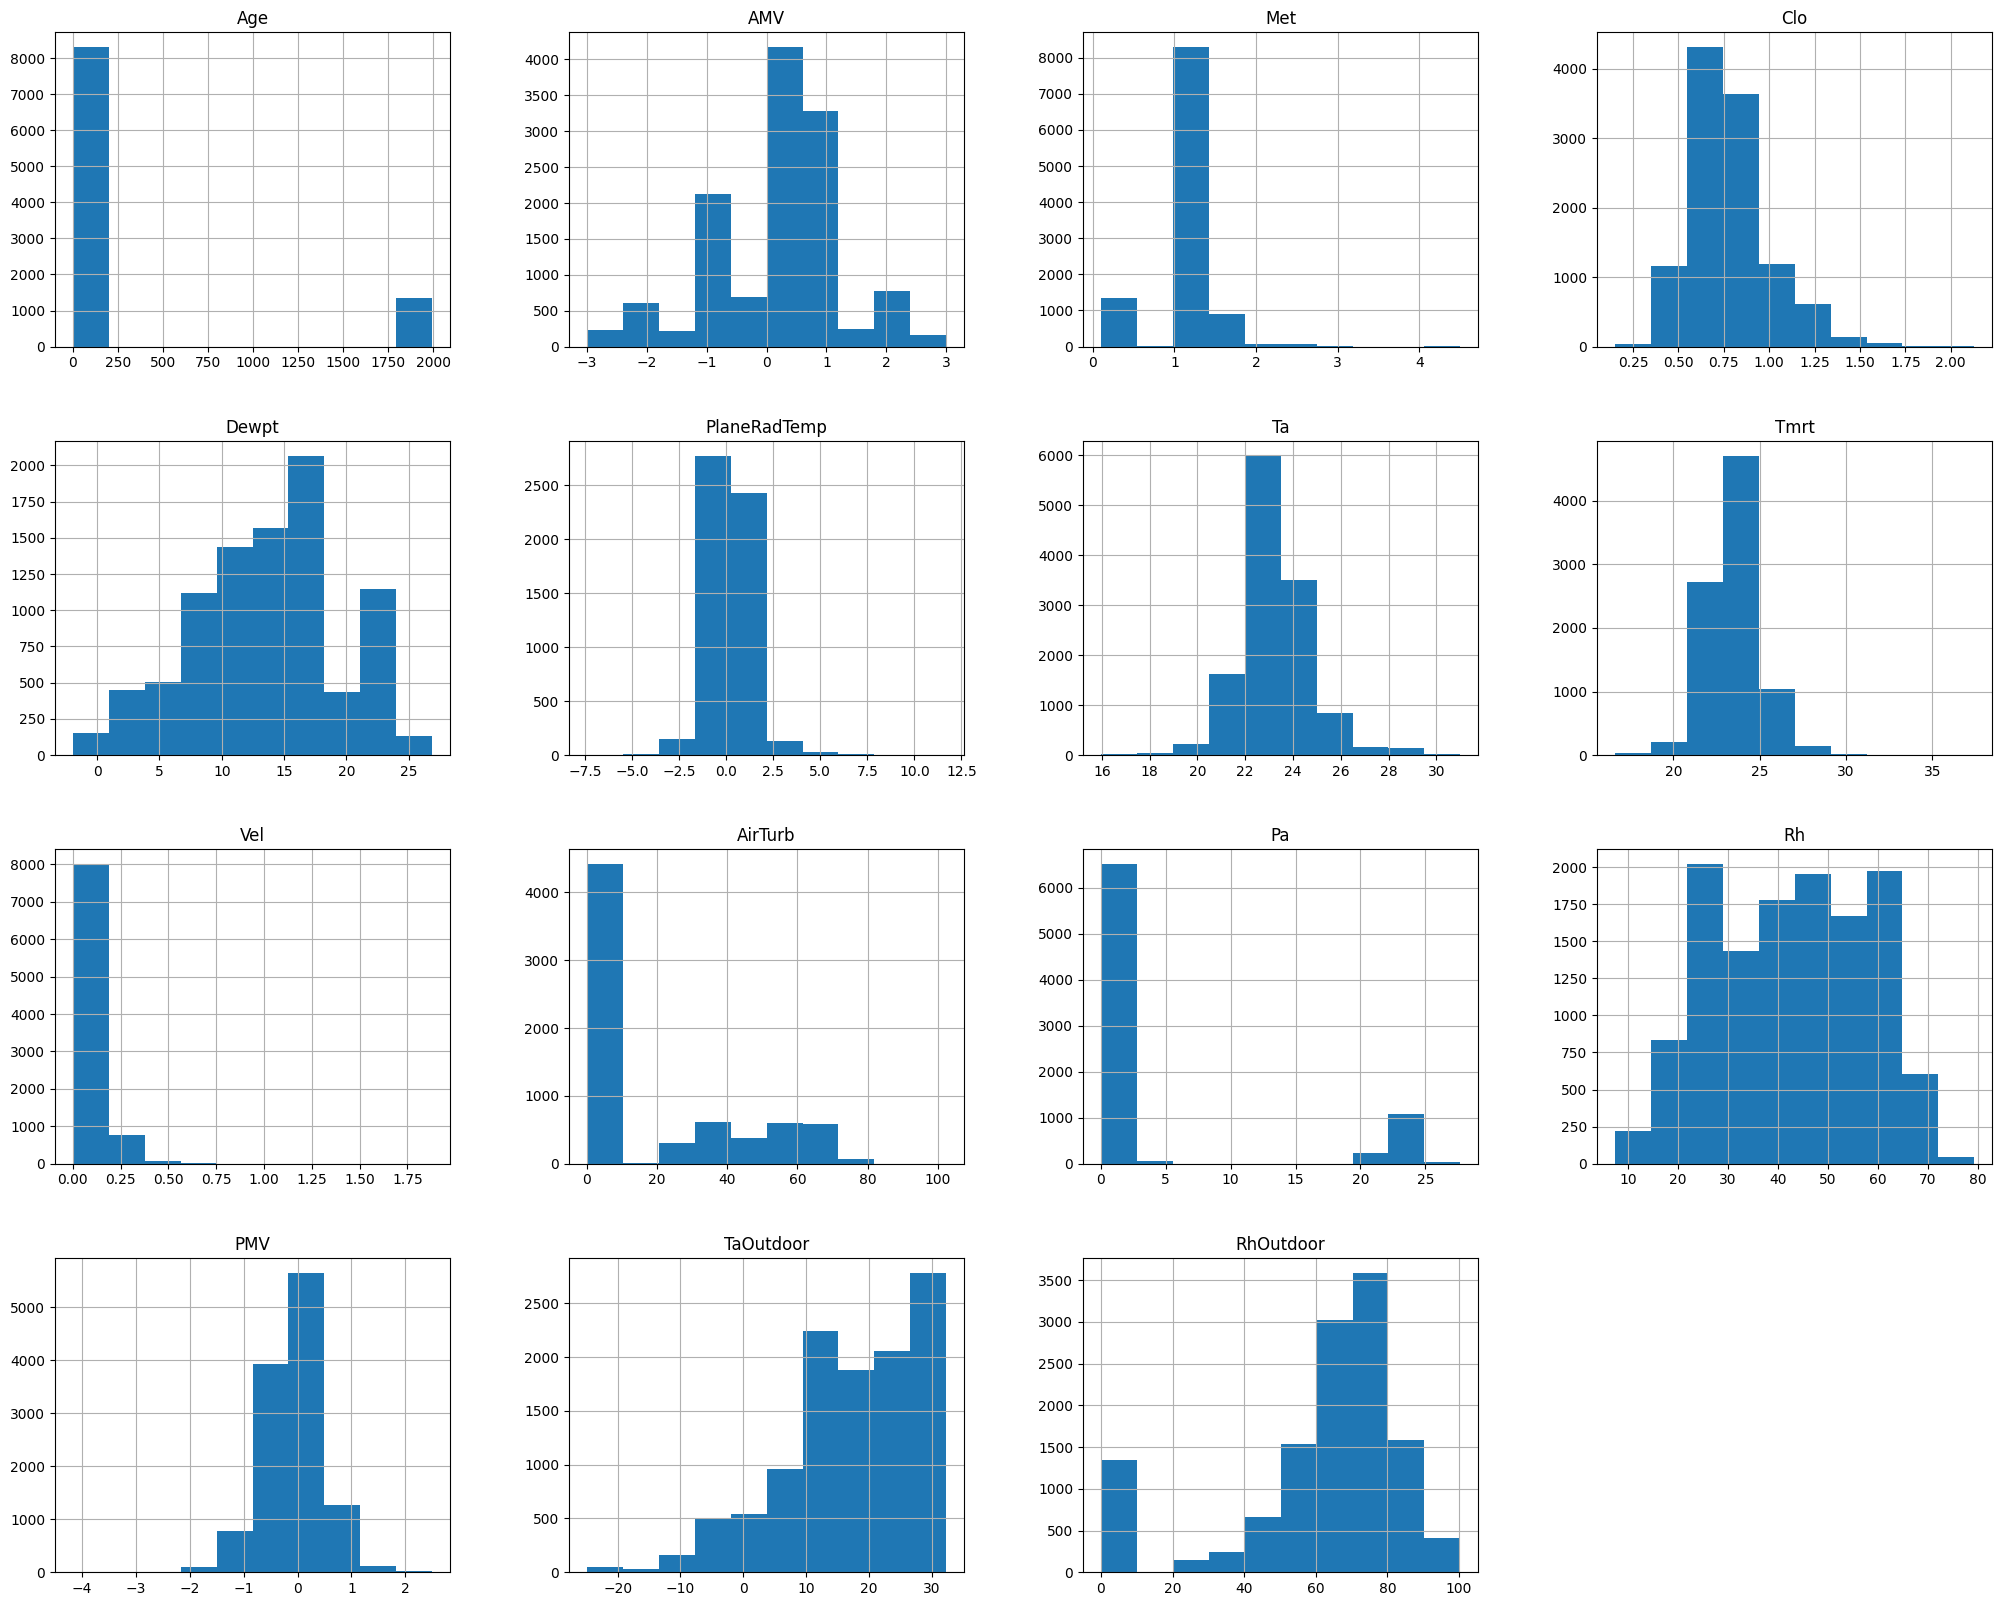

In [1625]:
hist = df.hist(figsize=[25,20])

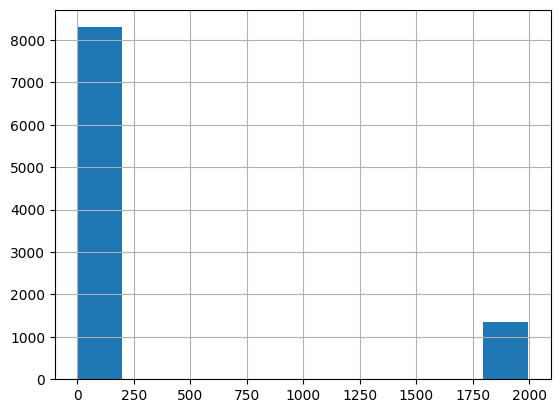

In [1626]:
hist = df['Age'].hist()

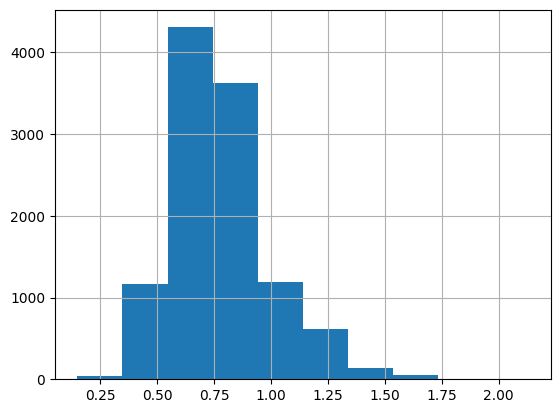

In [1627]:
hist = df['Clo'].hist()

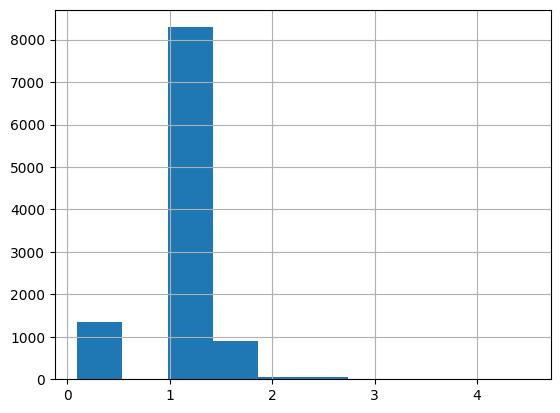

In [1628]:
hist = df['Met'].hist()

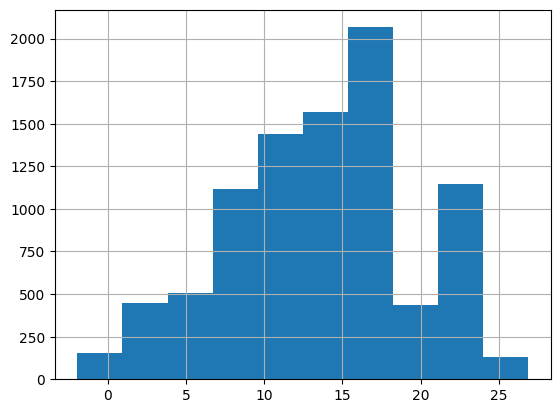

In [1629]:
hist = df['Dewpt'].hist()

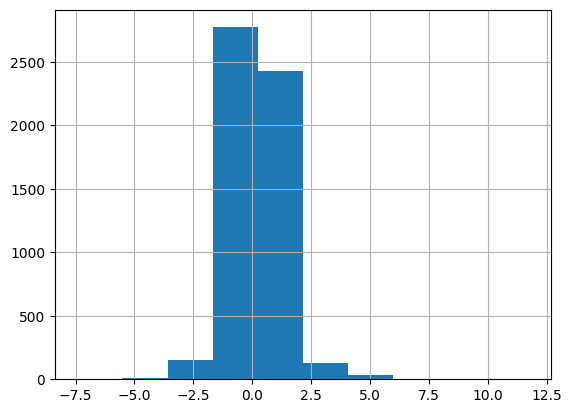

In [1630]:
hist = df['PlaneRadTemp'].hist()

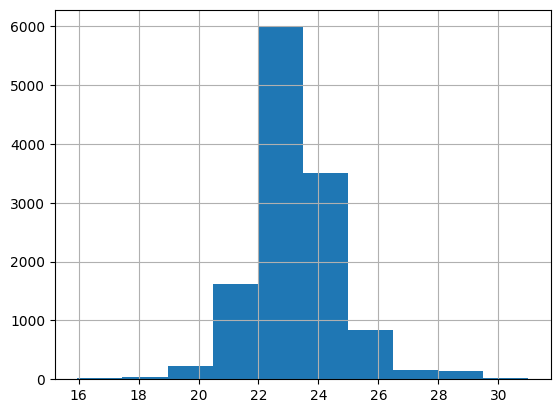

In [1631]:
hist = df['Ta'].hist()

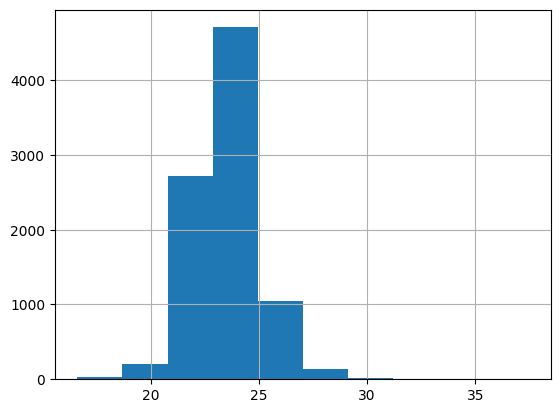

In [1632]:
hist = df['Tmrt'].hist()

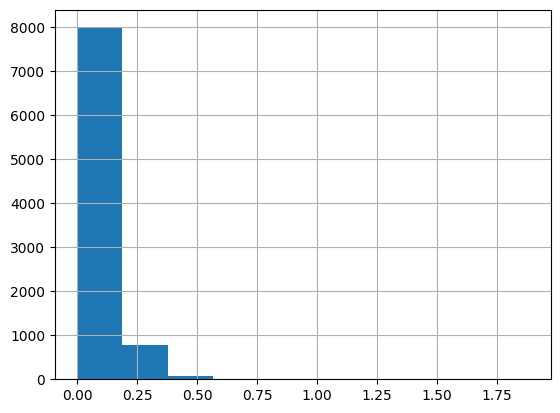

In [1633]:
hist = df['Vel'].hist()

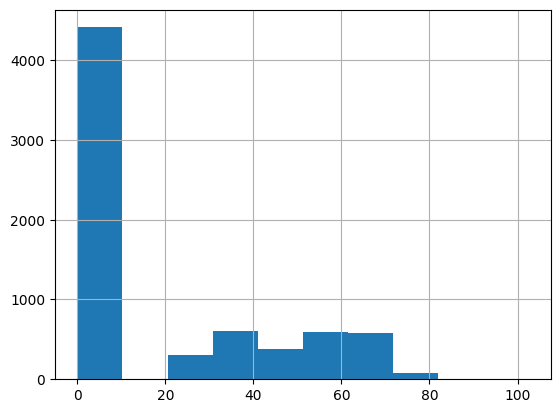

In [1634]:
hist = df['AirTurb'].hist()

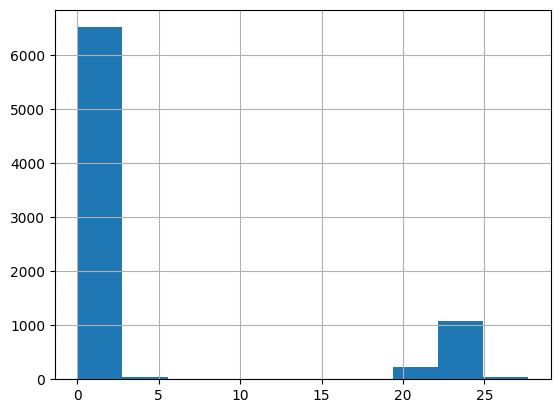

In [1635]:
hist = df['Pa'].hist()

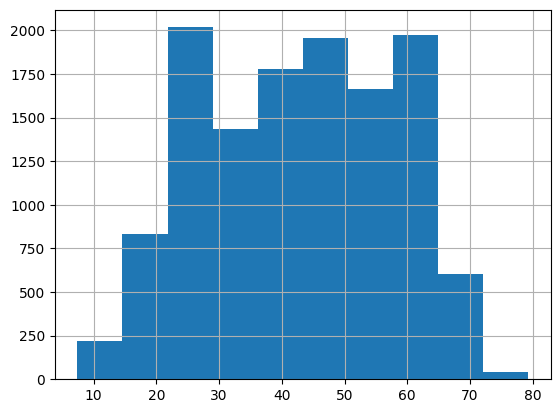

In [1636]:
hist = df['Rh'].hist()

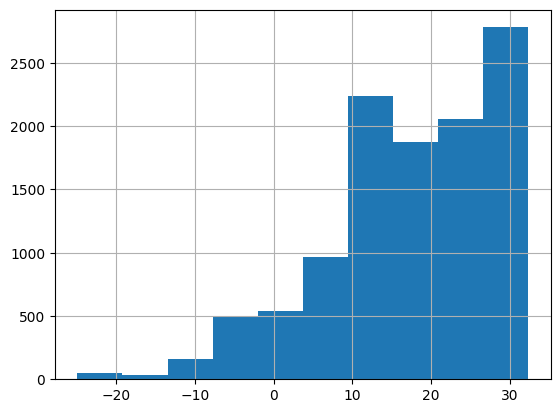

In [1637]:
hist = df['TaOutdoor'].hist()

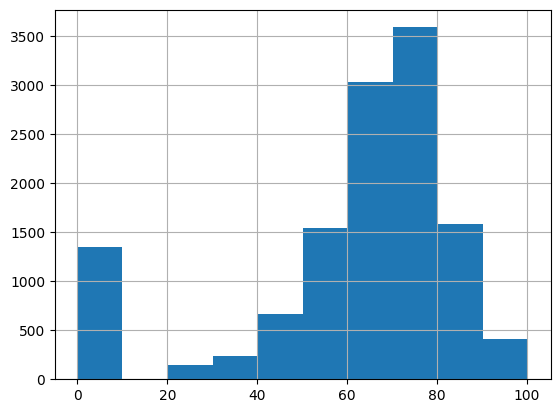

In [1638]:
hist = df['RhOutdoor'].hist()

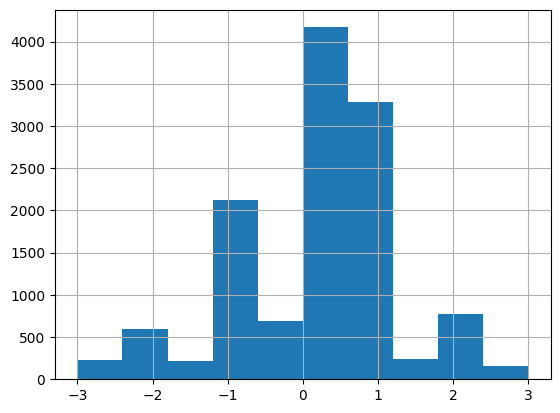

In [1639]:
hist = df['AMV'].hist()

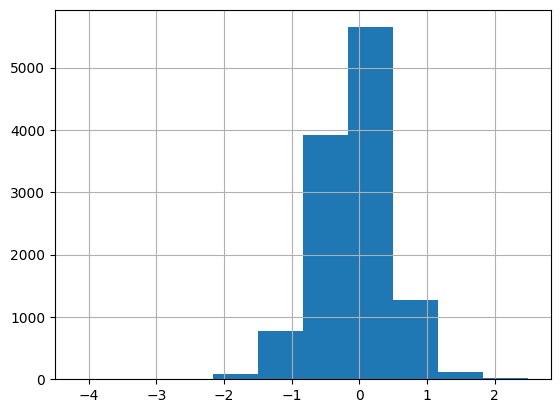

In [1640]:
hist = df['PMV'].hist()

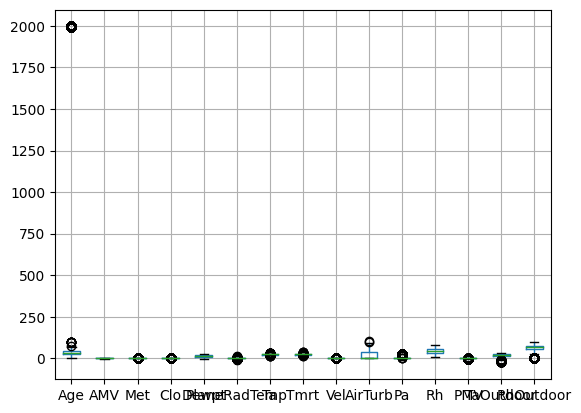

In [1641]:
boxplot = df.boxplot()

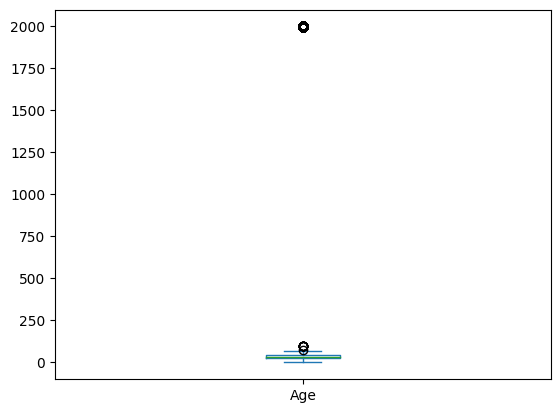

In [1642]:
df['Age'].plot(kind='box')
plt.show()

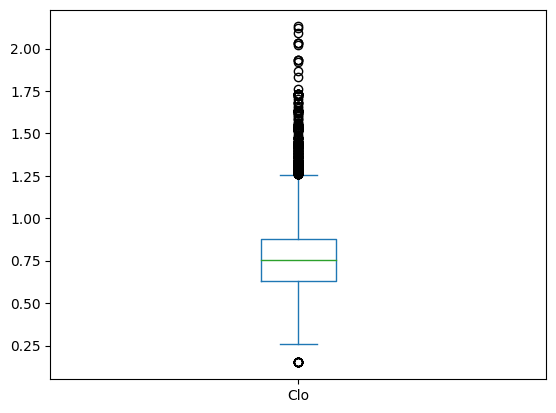

In [1643]:
df['Clo'].plot(kind='box')
plt.show()

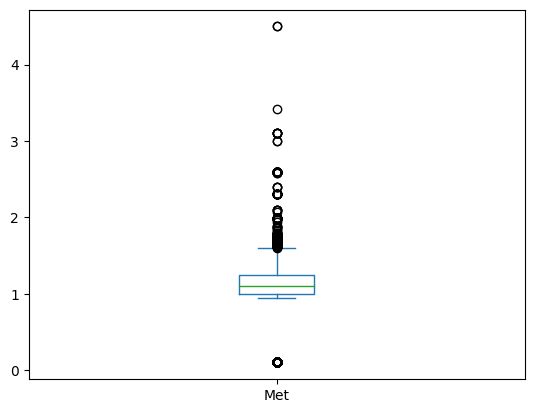

In [1644]:
df['Met'].plot(kind='box')
plt.show()

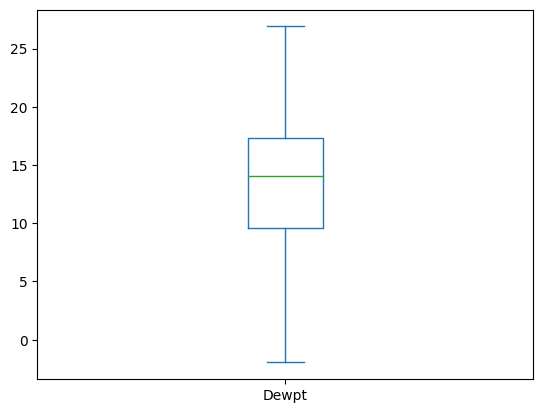

In [1645]:
df['Dewpt'].plot(kind='box')
plt.show()

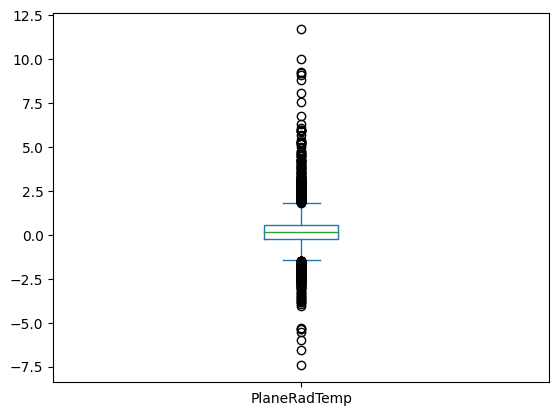

In [1646]:
df['PlaneRadTemp'].plot(kind='box')
plt.show()

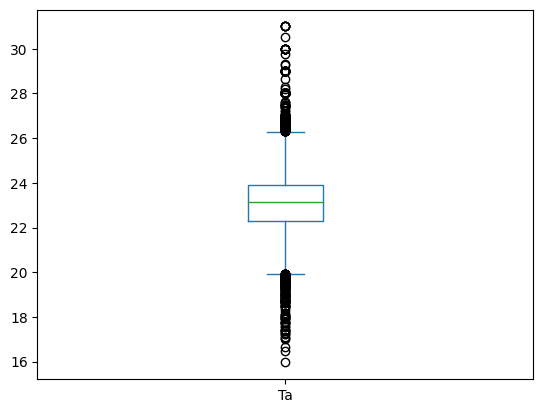

In [1647]:
df['Ta'].plot(kind='box')
plt.show()

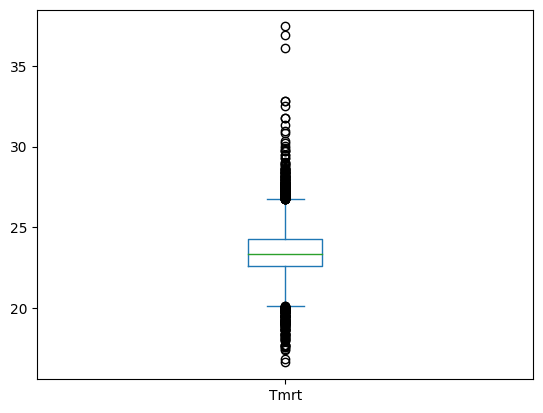

In [1648]:
df['Tmrt'].plot(kind='box')
plt.show()

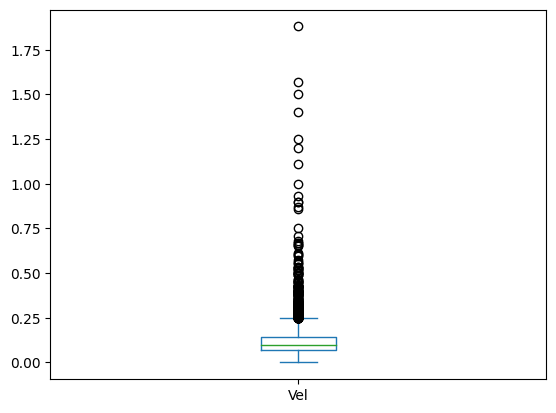

In [1649]:
df['Vel'].plot(kind='box')
plt.show()

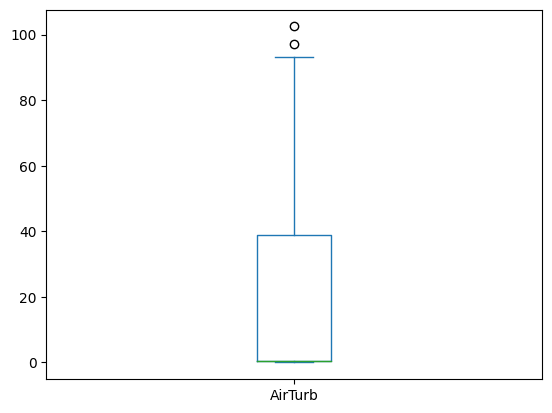

In [1650]:
df['AirTurb'].plot(kind='box')
plt.show()

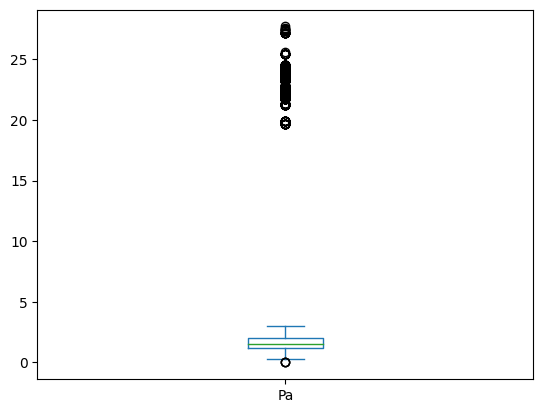

In [1651]:
df['Pa'].plot(kind='box')
plt.show()

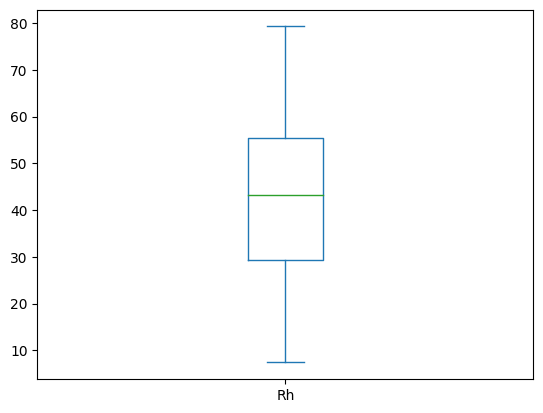

In [1652]:
df['Rh'].plot(kind='box')
plt.show()

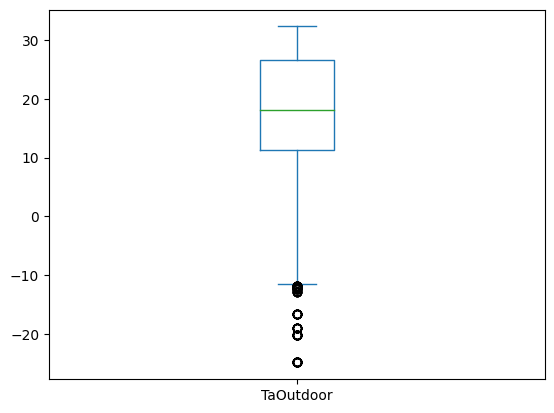

In [1653]:
df['TaOutdoor'].plot(kind='box')
plt.show()

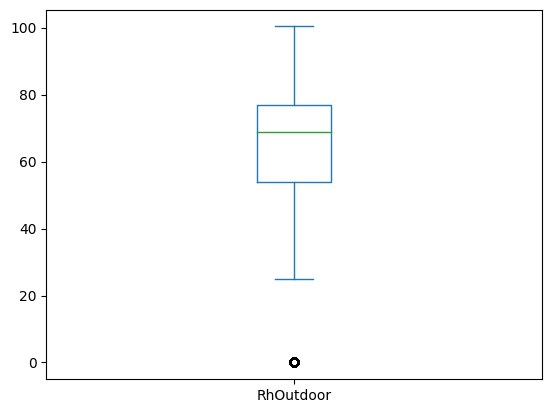

In [1654]:
df['RhOutdoor'].plot(kind='box')
plt.show()

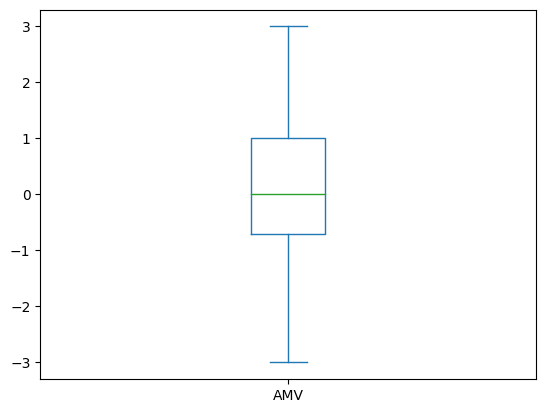

In [1655]:
df['AMV'].plot(kind='box')
plt.show()

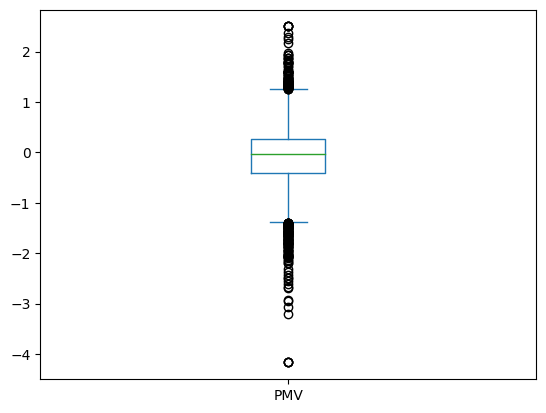

In [1656]:
df['PMV'].plot(kind='box')
plt.show()

# Question 3

In [1657]:
print('Missing Values : ')
df.isna().sum()

Missing Values : 


Age             2915
AMV               55
Met             1887
Clo             1406
Dewpt           3551
PlaneRadTemp    7021
Ta                20
Tmrt            3701
Vel             3700
AirTurb         5600
Pa              4655
Rh                35
PMV              696
TaOutdoor       1368
RhOutdoor         19
dtype: int64

In [1658]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values = np.nan, strategy='mean')
imp.fit(df)
df = pd.DataFrame(data=imp.transform(df), columns=df.columns)

In [1659]:
print('Missing Values : ')
df.isna().sum()

Missing Values : 


Age             0
AMV             0
Met             0
Clo             0
Dewpt           0
PlaneRadTemp    0
Ta              0
Tmrt            0
Vel             0
AirTurb         0
Pa              0
Rh              0
PMV             0
TaOutdoor       0
RhOutdoor       0
dtype: int64

# Question 4

In [1660]:
#create a function to find outliers using IQR

def find_outliers_IQR(df):

   q1=df.quantile(0.25)

   q3=df.quantile(0.75)

   IQR=q3-q1

   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]

   return outliers

In [1661]:
outliers = find_outliers_IQR(df['Age'])

print('number of outliers in Age: '+ str(len(outliers)))

print('max outlier value in Age: '+ str(outliers.max()))

print('min outlier value in Age: '+ str(outliers.min()))


number of outliers in Age: 1349
max outlier value in Age: 1996.0
min outlier value in Age: 1995.0


In [1662]:
outliers = find_outliers_IQR(df['Clo'])

print('number of outliers in Clo: '+ str(len(outliers)))

print('max outlier value in Clo: '+ str(outliers.max()))

print('min outlier value in Clo: '+ str(outliers.min()))

number of outliers in Clo: 782
max outlier value in Clo: 2.13
min outlier value in Clo: 0.15


In [1663]:
outliers = find_outliers_IQR(df['Met'])

print('number of outliers in Met: '+ str(len(outliers)))

print('max outlier value in Met: '+ str(outliers.max()))

print('min outlier value in Met: '+ str(outliers.min()))

number of outliers in Met: 2127
max outlier value in Met: 4.5
min outlier value in Met: 0.1


In [1664]:
outliers = find_outliers_IQR(df['Dewpt'])

print('number of outliers in Dewpt: '+ str(len(outliers)))

print('max outlier value in Dewpt: '+ str(outliers.max()))

print('min outlier value in Dewpt: '+ str(outliers.min()))

number of outliers in Dewpt: 789
max outlier value in Dewpt: 26.89675
min outlier value in Dewpt: -1.953


In [1665]:
outliers = find_outliers_IQR(df['PlaneRadTemp'])

print('number of outliers in PlaneRadTemp: '+ str(len(outliers)))

print('max outlier value in PlaneRadTemp: '+ str(outliers.max()))

print('min outlier value in PlaneRadTemp: '+ str(outliers.min()))

number of outliers in PlaneRadTemp: 5544
max outlier value in PlaneRadTemp: 11.7
min outlier value in PlaneRadTemp: -7.42


In [1666]:
outliers = find_outliers_IQR(df['Ta'])

print('number of outliers in Ta: '+ str(len(outliers)))

print('max outlier value in Ta: '+ str(outliers.max()))

print('min outlier value in Ta: '+ str(outliers.min()))

number of outliers in Ta: 539
max outlier value in Ta: 31.0
min outlier value in Ta: 15.96


In [1667]:
outliers = find_outliers_IQR(df['Tmrt'])

print('number of outliers in Tmrt: '+ str(len(outliers)))

print('max outlier value in Tmrt: '+ str(outliers.max()))

print('min outlier value in Tmrt: '+ str(outliers.min()))

number of outliers in Tmrt: 1620
max outlier value in Tmrt: 37.445
min outlier value in Tmrt: 16.61


In [1668]:
outliers = find_outliers_IQR(df['Vel'])

print('number of outliers in Vel: '+ str(len(outliers)))

print('max outlier value in Vel: '+ str(outliers.max()))

print('min outlier value in Vel: '+ str(outliers.min()))

number of outliers in Vel: 1261
max outlier value in Vel: 1.88
min outlier value in Vel: 0.0


In [1669]:
outliers = find_outliers_IQR(df['AirTurb'])

print('number of outliers in AirTurb: '+ str(len(outliers)))

print('max outlier value in AirTurb: '+ str(outliers.max()))

print('min outlier value in AirTurb: '+ str(outliers.min()))

number of outliers in AirTurb: 1444
max outlier value in AirTurb: 102.45
min outlier value in AirTurb: 44.99


In [1670]:
outliers = find_outliers_IQR(df['Pa'])

print('number of outliers in Pa: '+ str(len(outliers)))

print('max outlier value in Pa: '+ str(outliers.max()))

print('min outlier value in Pa: '+ str(outliers.min()))

number of outliers in Pa: 1349
max outlier value in Pa: 27.7
min outlier value in Pa: 19.7


In [1671]:
outliers = find_outliers_IQR(df['Rh'])

print('number of outliers in Rh: '+ str(len(outliers)))

print('max outlier value in Rh: '+ str(outliers.max()))

print('min outlier value in Rh: '+ str(outliers.min()))

number of outliers in Rh: 0
max outlier value in Rh: nan
min outlier value in Rh: nan


In [1672]:
outliers = find_outliers_IQR(df['TaOutdoor'])

print('number of outliers in TaOutdoor: '+ str(len(outliers)))

print('max outlier value in TaOutdoor: '+ str(outliers.max()))

print('min outlier value in TaOutdoor: '+ str(outliers.min()))

number of outliers in TaOutdoor: 221
max outlier value in TaOutdoor: -8.1
min outlier value in TaOutdoor: -24.9


In [1673]:
outliers = find_outliers_IQR(df['RhOutdoor'])

print('number of outliers in RhOutdoor: '+ str(len(outliers)))

print('max outlier value in RhOutdoor: '+ str(outliers.max()))

print('min outlier value in RhOutdoor: '+ str(outliers.min()))

number of outliers in RhOutdoor: 1349
max outlier value in RhOutdoor: 0.0
min outlier value in RhOutdoor: 0.0


In [1674]:
outliers = find_outliers_IQR(df['AMV'])

print('number of outliers in AMV: '+ str(len(outliers)))

print('max outlier value in AMV: '+ str(outliers.max()))

print('min outlier value in AMV: '+ str(outliers.min()))

number of outliers in AMV: 0
max outlier value in AMV: nan
min outlier value in AMV: nan


In [1675]:
outliers = find_outliers_IQR(df['PMV'])

print('number of outliers in PMV: '+ str(len(outliers)))

print('max outlier value in PMV: '+ str(outliers.max()))

print('min outlier value in PMV: '+ str(outliers.min()))

number of outliers in PMV: 346
max outlier value in PMV: 2.5
min outlier value in PMV: -4.17


array([[<AxesSubplot: title={'center': 'Age'}>,
        <AxesSubplot: title={'center': 'AMV'}>,
        <AxesSubplot: title={'center': 'Met'}>,
        <AxesSubplot: title={'center': 'Clo'}>],
       [<AxesSubplot: title={'center': 'Dewpt'}>,
        <AxesSubplot: title={'center': 'PlaneRadTemp'}>,
        <AxesSubplot: title={'center': 'Ta'}>,
        <AxesSubplot: title={'center': 'Tmrt'}>],
       [<AxesSubplot: title={'center': 'Vel'}>,
        <AxesSubplot: title={'center': 'AirTurb'}>,
        <AxesSubplot: title={'center': 'Pa'}>,
        <AxesSubplot: title={'center': 'Rh'}>],
       [<AxesSubplot: title={'center': 'PMV'}>,
        <AxesSubplot: title={'center': 'TaOutdoor'}>,
        <AxesSubplot: title={'center': 'RhOutdoor'}>, <AxesSubplot: >]],
      dtype=object)

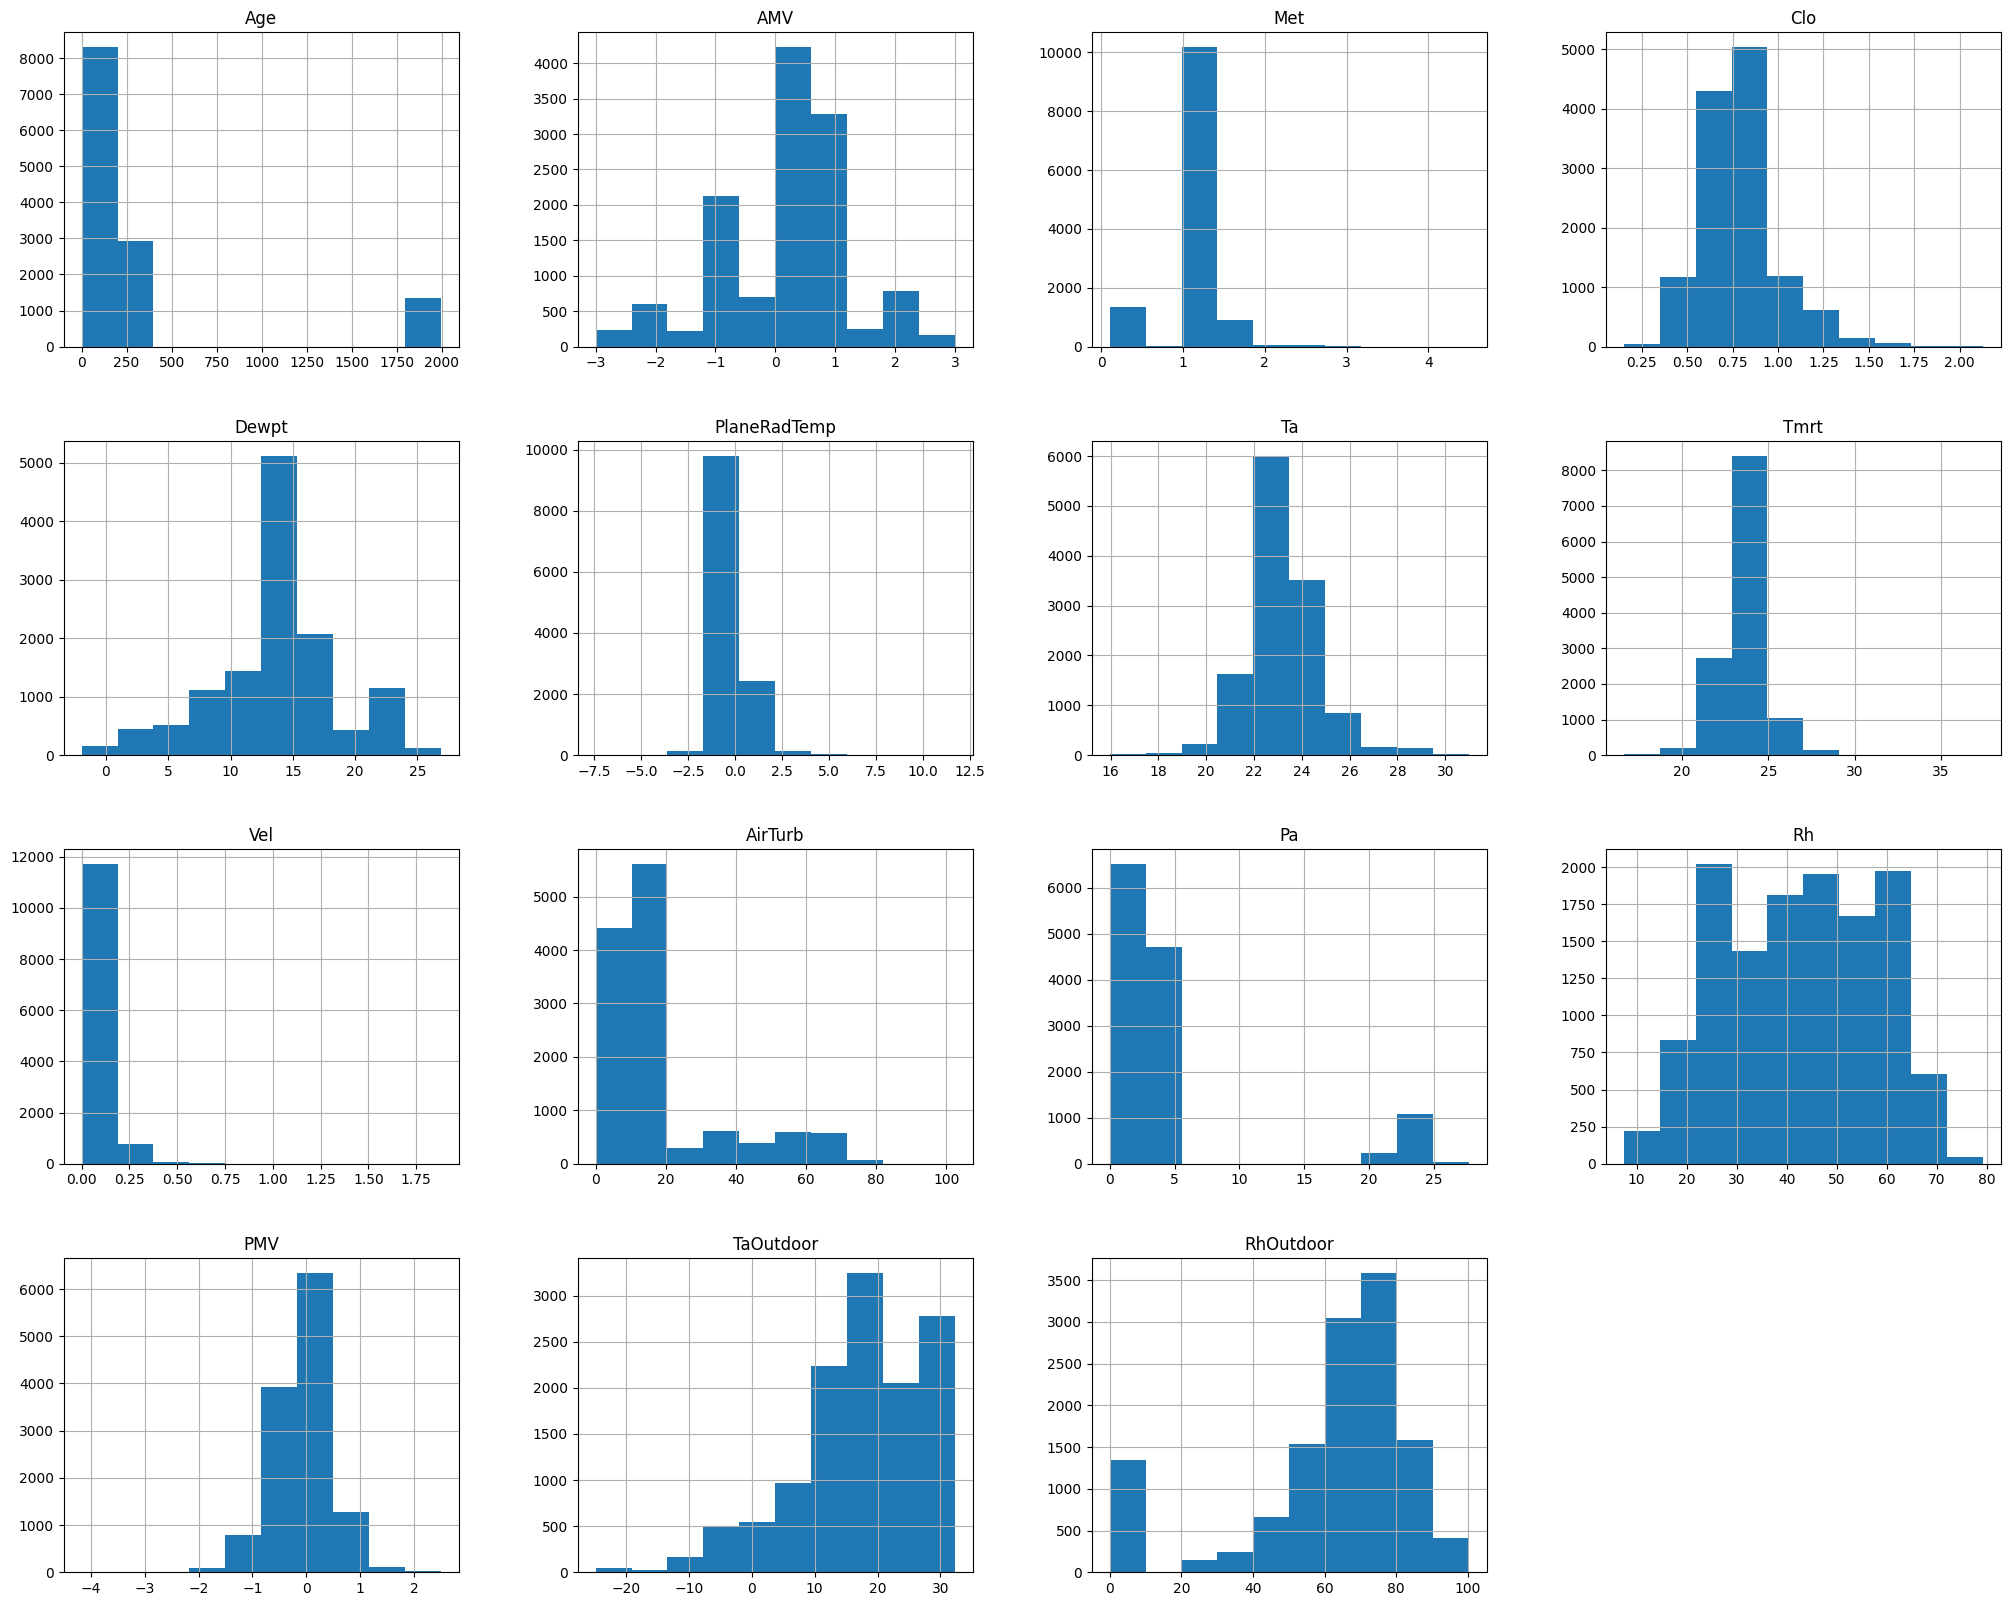

In [1676]:
df.hist(figsize=[25,20])

In [1677]:
max_threshold = df.quantile(0.85)
df[df>max_threshold]

,Age,AMV,Met,Clo,Dewpt,PlaneRadTemp,Ta,Tmrt,Vel,AirTurb,Pa,Rh,PMV,TaOutdoor,RhOutdoor
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.3,NaN,28.2,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.5,NaN,30.3,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,NaN,NaN,68.5,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1678]:
min_threshold = df.quantile(0.05)
df[df<min_threshold]

,Age,AMV,Met,Clo,Dewpt,PlaneRadTemp,Ta,Tmrt,Vel,AirTurb,Pa,Rh,PMV,TaOutdoor,RhOutdoor
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.17,NaN,NaN
12561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1679]:
df=df[(df<max_threshold) & (df>min_threshold)]
df

,Age,AMV,Met,Clo,Dewpt,PlaneRadTemp,Ta,Tmrt,Vel,AirTurb,Pa,Rh,PMV,TaOutdoor,RhOutdoor
0,NaN,-1.000000,1.100000,0.712644,13.621447,0.217785,22.800000,23.454100,0.130000,18.26587,NaN,58.900000,-0.320000,NaN,70.600000
1,NaN,-1.000000,1.100000,0.798463,13.621447,0.217785,22.800000,23.565916,0.140000,18.26587,NaN,59.100000,-0.160000,NaN,70.600000
2,NaN,0.000000,1.100000,0.575919,13.621447,0.217785,23.700000,24.026890,0.130000,18.26587,NaN,NaN,-0.370000,NaN,75.450000
3,NaN,0.000000,1.100000,0.696050,13.621447,0.217785,22.800000,23.018110,0.130000,18.26587,NaN,NaN,-0.300000,NaN,75.450000
4,NaN,0.000000,1.100000,0.696050,13.621447,0.217785,23.000000,23.439303,NaN,18.26587,NaN,NaN,-0.310000,27.500000,75.450000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12560,NaN,0.100584,1.065907,0.778503,13.621447,0.217785,23.179187,23.450693,0.112445,18.26587,NaN,42.528507,NaN,17.175087,61.098939
12561,NaN,0.100584,1.065907,0.778503,13.621447,0.217785,23.179187,23.450693,0.112445,18.26587,NaN,42.528507,-0.620000,17.175087,61.098939
12562,NaN,0.100584,1.065907,0.778503,13.621447,0.217785,23.179187,23.450693,0.112445,18.26587,NaN,42.528507,-0.073711,17.175087,61.098939
12563,NaN,0.100584,1.065907,0.778503,13.621447,0.217785,23.179187,23.450693,0.112445,18.26587,NaN,42.528507,-0.073711,17.175087,61.098939


array([[<AxesSubplot: title={'center': 'Age'}>,
        <AxesSubplot: title={'center': 'AMV'}>,
        <AxesSubplot: title={'center': 'Met'}>,
        <AxesSubplot: title={'center': 'Clo'}>],
       [<AxesSubplot: title={'center': 'Dewpt'}>,
        <AxesSubplot: title={'center': 'PlaneRadTemp'}>,
        <AxesSubplot: title={'center': 'Ta'}>,
        <AxesSubplot: title={'center': 'Tmrt'}>],
       [<AxesSubplot: title={'center': 'Vel'}>,
        <AxesSubplot: title={'center': 'AirTurb'}>,
        <AxesSubplot: title={'center': 'Pa'}>,
        <AxesSubplot: title={'center': 'Rh'}>],
       [<AxesSubplot: title={'center': 'PMV'}>,
        <AxesSubplot: title={'center': 'TaOutdoor'}>,
        <AxesSubplot: title={'center': 'RhOutdoor'}>, <AxesSubplot: >]],
      dtype=object)

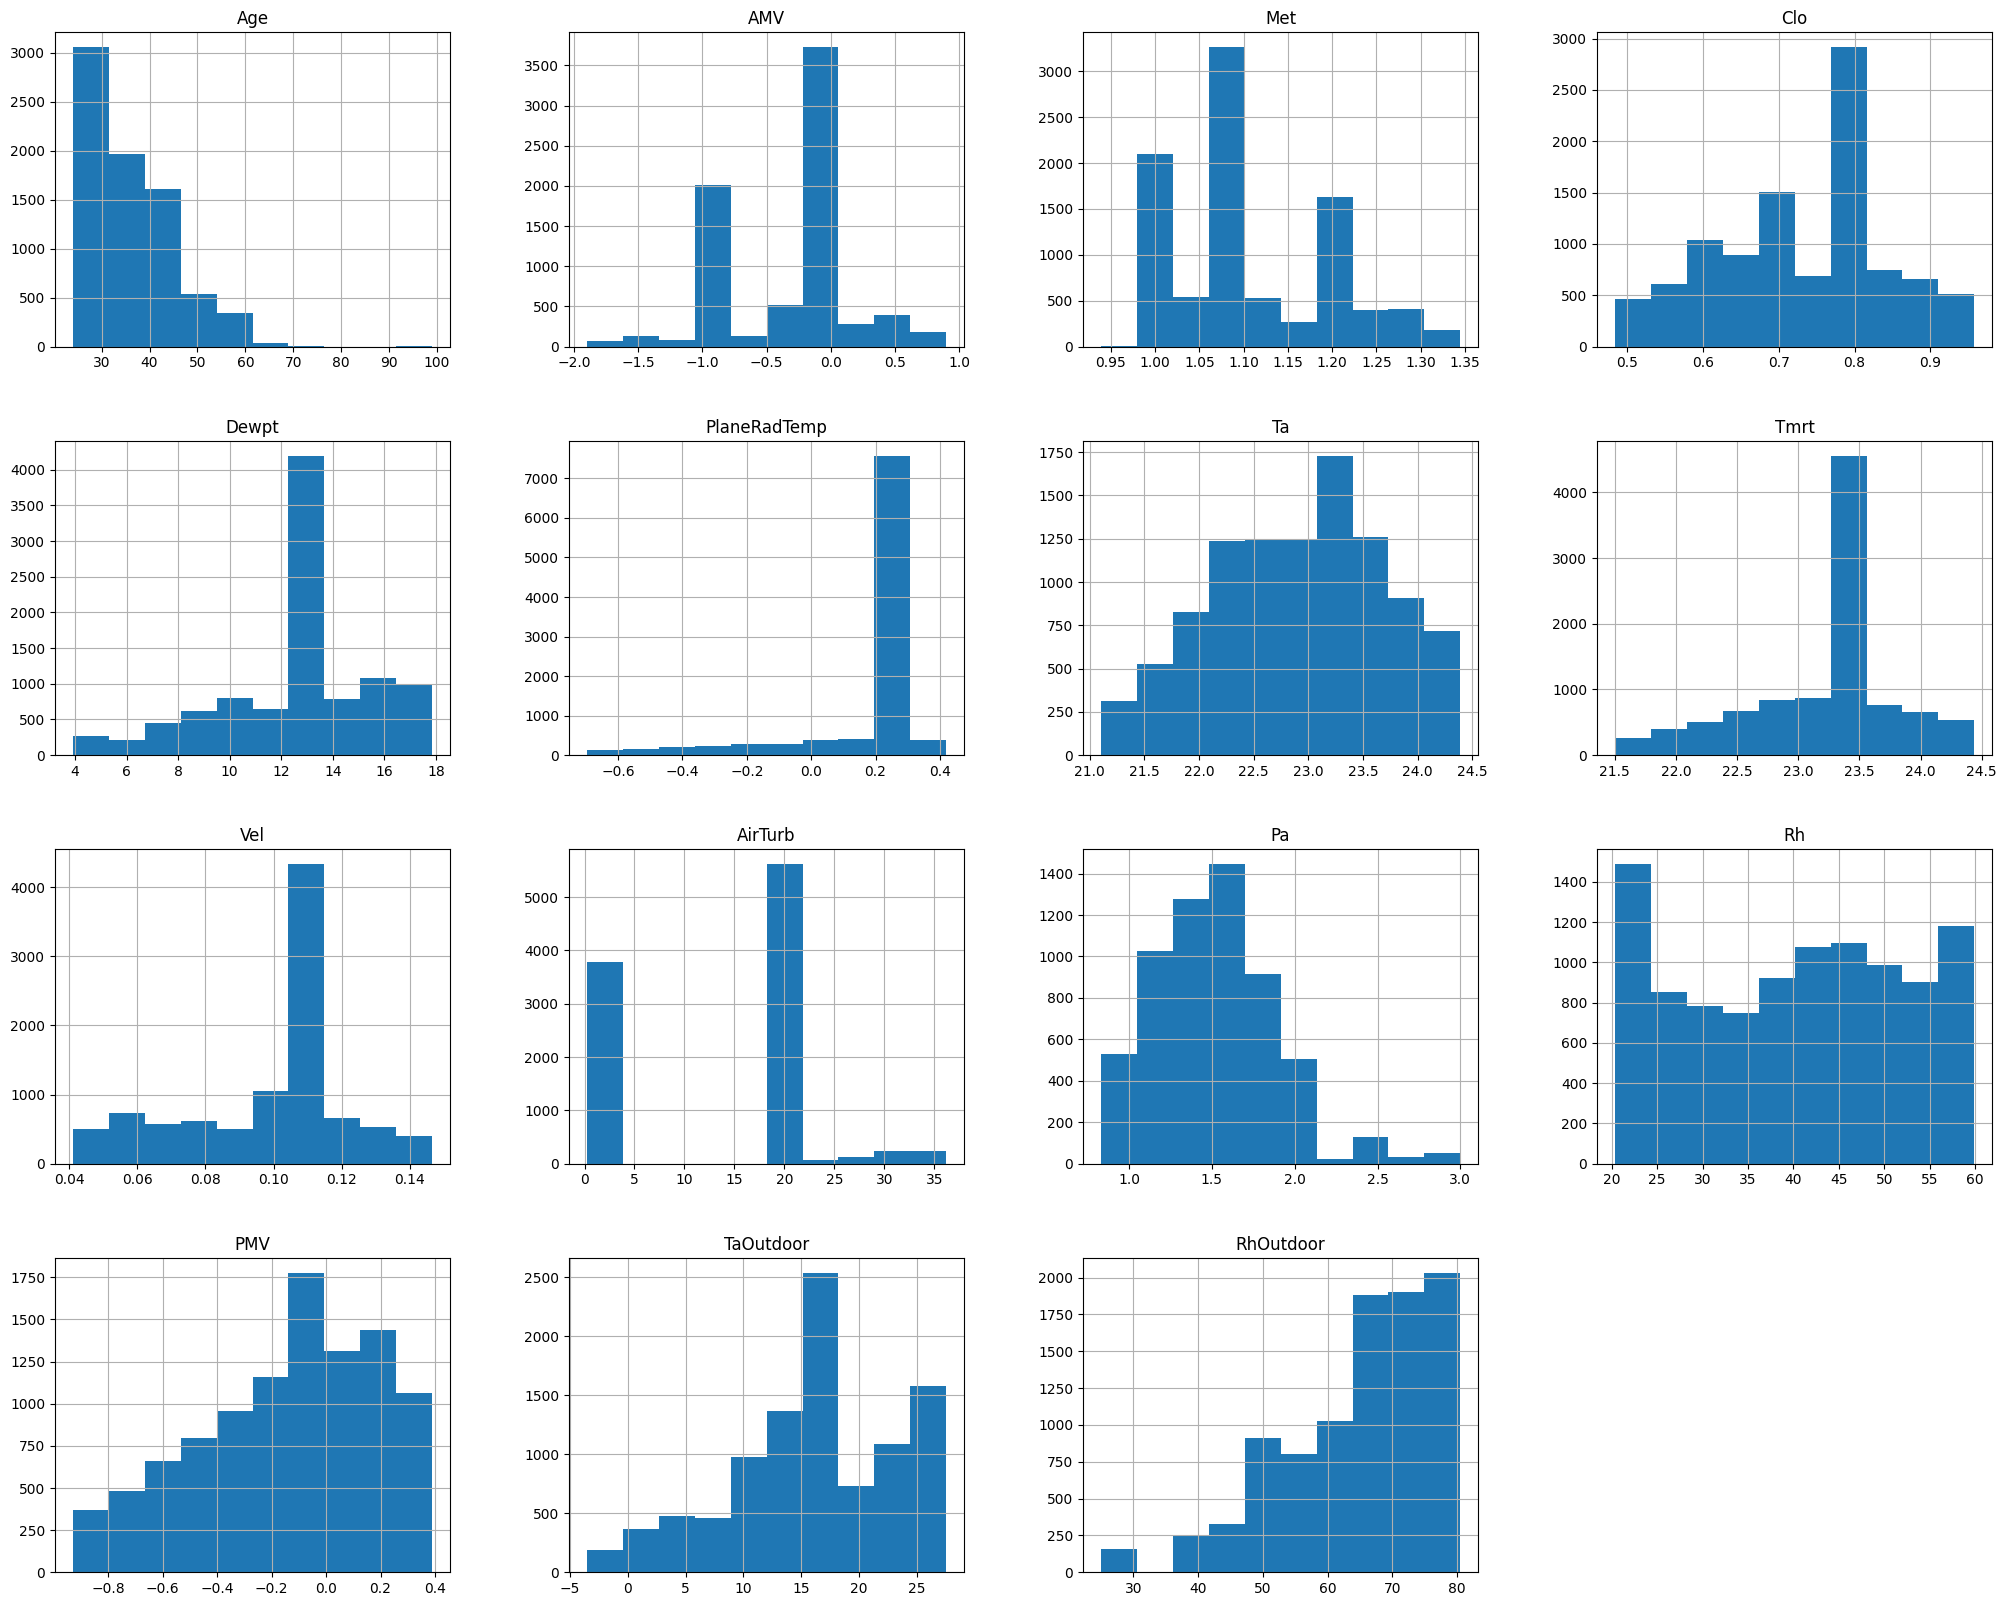

In [1680]:
df.hist(figsize=[25,20])

Question 6

In [1681]:
df['Age'].sample(10)

5271     38.0
4910     35.0
5535     38.0
8614      NaN
6146     42.0
7919     54.0
6205     42.0
10824     NaN
5573     38.0
10455     NaN
Name: Age, dtype: float64

In [1682]:
df.var()

Age              93.775199
AMV               0.302048
Met               0.007974
Clo               0.011911
Dewpt             9.036154
PlaneRadTemp      0.036436
Ta                0.605578
Tmrt              0.364805
Vel               0.000561
AirTurb          95.522749
Pa                0.140181
Rh              142.197679
PMV               0.108109
TaOutdoor        51.740293
RhOutdoor       135.239843
dtype: float64

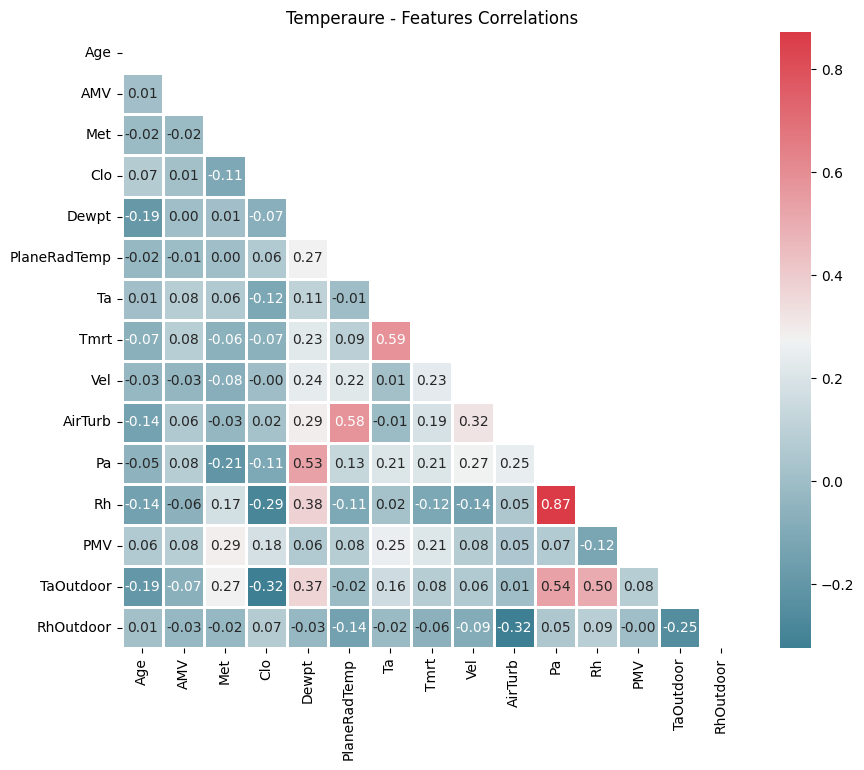

In [1683]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(10,8))
colormap = sns.diverging_palette(220, 10, as_cmap=True)
dropSelf = np.zeros_like(corr)
dropSelf[np.triu_indices_from(dropSelf)] = True
colormap = sns.diverging_palette(220, 10,as_cmap=True )
sns.heatmap(corr, cmap=colormap, linewidths= 1, annot=True, fmt='.2f', mask = dropSelf)
plt.title('Temperaure - Features Correlations')
plt.show()

Question 7

In [1684]:
def compute_impurity(feature):
  
    probs = feature.value_counts(normalize=True)
    
    impurity = -1 * np.sum(np.log2(probs) * probs)
        
    return(round(impurity, 3))

print('impurity using entropy:', compute_impurity(df))

impurity using entropy: 8.114


In [1685]:
target_entropy = compute_impurity(df['Age'])
print('Entropy of Age: ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Age'])
print('Information Gain of Age : ', info_gain)
print(" ")

target_entropy = compute_impurity(df['Clo'])
print('Entropy of Clo : ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Clo'])
print('Information Gain of Clo: ', info_gain)
print(" ")

target_entropy = compute_impurity(df['Met'])
print('Entropy of Met: ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Met'])
print('Information Gain of Met : ', info_gain)
print(" ")

target_entropy = compute_impurity(df['Dewpt'])
print('Entropy of Dewpt : ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Dewpt'])
print('Information Gain of Dewpt: ', info_gain)
print(" ")

target_entropy = compute_impurity(df['PlaneRadTemp'])
print('Entropy of PlaneRadTemp: ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['PlaneRadTemp'])
print('Information Gain of PlaneRadTemp : ', info_gain)
print(" ")

target_entropy = compute_impurity(df['Ta'])
print('Entropy of Ta : ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Ta'])
print('Information Gain of Ta: ', info_gain)
print(" ")

target_entropy = compute_impurity(df['Tmrt'])
print('Entropy of Tmrt: ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Tmrt'])
print('Information Gain of Tmrt : ', info_gain)
print(" ")

target_entropy = compute_impurity(df['Vel'])
print('Entropy of Vel : ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Vel'])
print('Information Gain of Vel: ', info_gain)
print(" ")

target_entropy = compute_impurity(df['AirTurb'])
print('Entropy of AirTurb: ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['AirTurb'])
print('Information Gain of AirTurb : ', info_gain)
print(" ")

target_entropy = compute_impurity(df['Pa'])
print('Entropy of Pa : ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Pa'])
print('Information Gain of Pa: ', info_gain)
print(" ")

target_entropy = compute_impurity(df['Rh'])
print('Entropy of Rh: ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['Rh'])
print('Information Gain of Rh : ', info_gain)
print(" ")

target_entropy = compute_impurity(df['TaOutdoor'])
print('Entropy of TaOutdoor : ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['TaOutdoor'])
print('Information Gain of TaOutdoor: ', info_gain)
print(" ")

target_entropy = compute_impurity(df['RhOutdoor'])
print('Entropy of RhOutdoor: ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['RhOutdoor'])
print('Information Gain of RhOutdoor : ', info_gain)
print(" ")

target_entropy = compute_impurity(df['AMV'])
print('Entropy of AMV : ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['AMV'])
print('Information Gain of AMV: ', info_gain)
print(" ")

target_entropy = compute_impurity(df['PMV'])
print('Entropy of PMV: ' ,target_entropy)

info_gain = compute_impurity(df) - compute_impurity(df['PMV'])
print('Information Gain of PMV : ', info_gain)

Entropy of Age:  4.519
Information Gain of Age :  3.5950000000000006
 
Entropy of Clo :  6.683
Information Gain of Clo:  1.431000000000001
 
Entropy of Met:  4.39
Information Gain of Met :  3.724000000000001
 
Entropy of Dewpt :  6.983
Information Gain of Dewpt:  1.1310000000000011
 
Entropy of PlaneRadTemp:  3.404
Information Gain of PlaneRadTemp :  4.710000000000001
 
Entropy of Ta :  7.713
Information Gain of Ta:  0.4010000000000007
 
Entropy of Tmrt:  6.922
Information Gain of Tmrt :  1.192000000000001
 
Entropy of Vel :  4.327
Information Gain of Vel:  3.787000000000001
 
Entropy of AirTurb:  4.928
Information Gain of AirTurb :  3.186000000000001
 
Entropy of Pa :  10.256
Information Gain of Pa:  -2.1419999999999995
 
Entropy of Rh:  10.702
Information Gain of Rh :  -2.587999999999999
 
Entropy of TaOutdoor :  7.301
Information Gain of TaOutdoor:  0.8130000000000006
 
Entropy of RhOutdoor:  7.307
Information Gain of RhOutdoor :  0.8070000000000004
 
Entropy of AMV :  2.707
Informa

PART B

In [1686]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values = np.nan, strategy='mean')
imp.fit(df)
df = pd.DataFrame(data=imp.transform(df), columns=df.columns)

Question 1 and 2

In [1687]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
X = df.drop(['PMV'] , axis = 1)
Y = df['PMV']

mlr = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2 , random_state = 100)
print(X_train.shape)
print(y_train.shape)
sfs1 = sfs(mlr,
           k_features=5,
           forward=True,
           floating=False,
           scoring='neg_mean_squared_error',
           cv=0)

sfs1 = sfs1.fit(X, Y)
feat_cols = list(sfs1.k_feature_names_)
print(feat_cols)

(10052, 14)
(10052,)
['Met', 'Clo', 'Ta', 'Tmrt', 'Rh']


In [1688]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
X = df.drop(['PMV'] , axis = 1)
Y = df['PMV']

mlr = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2 , random_state = 100)
print(X_train.shape)
print(y_train.shape)
sfs1 = sfs(mlr,
           k_features=5,
           forward=False,
           floating=False,
           scoring='neg_mean_squared_error',
           cv=0)

sfs1 = sfs1.fit(X, Y)
feat_cols = list(sfs1.k_feature_names_)
print(feat_cols)

(10052, 14)
(10052,)
['Met', 'Clo', 'Ta', 'Pa', 'Rh']


Question 3

In [1689]:
#importing the necessary libraries
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression
# Sequential Forward Selection(sfs)
sfs = SFS(LinearRegression(),
          k_features=5,
          forward=True,
          floating=False,
          scoring = 'r2',
          cv = 0)
sfs.fit(X, y)
sfs.k_feature_names_

('Met', 'Clo', 'Ta', 'Tmrt', 'Rh')

In [1690]:
from sklearn import preprocessing
from sklearn import utils
from sklearn.linear_model import LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
X = df.drop(['AMV'] , axis = 1)
Y = df['AMV']

from sklearn import preprocessing
from sklearn import utils

#convert y values to categorical values
lab = preprocessing.LabelEncoder()
y_transformed = lab.fit_transform(Y)

clf = LogisticRegression()
clf.fit(X,y_transformed)

print("LogisticRegression")
print(clf.predict(X_test))

LogisticRegression
[16 16 16 ... 16 16 16]


D:\DATA SCIENCE\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\DATA SCIENCE\lib\site-packages\sklearn\base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- AMV
Feature names seen at fit time, yet now missing:
- PMV

  warnings.warn(message, FutureWarning)


In [1691]:
#Sequential backward selection(sbs)
sbs = SFS(LinearRegression(),
         k_features=5,
         forward=False,
         floating=False,
         cv=0)
sbs.fit(X, y)
sbs.k_feature_names_

('Age', 'Met', 'Clo', 'Dewpt', 'PMV')

In [1692]:
from sklearn import preprocessing
from sklearn import utils
from sklearn.linear_model import LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
X = df.drop(['AMV'] , axis = 1)
Y = df['AMV']

from sklearn import preprocessing
from sklearn import utils

#convert y values to categorical values
lab = preprocessing.LabelEncoder()
y_transformed = lab.fit_transform(Y)

clf = LogisticRegression()
clf.fit(X,y_transformed)

print("LogisticRegression")
clf=clf.predict(X_test)
print(clf)

LogisticRegression
[16 16 16 ... 16 16 16]


D:\DATA SCIENCE\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\DATA SCIENCE\lib\site-packages\sklearn\base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- AMV
Feature names seen at fit time, yet now missing:
- PMV

  warnings.warn(message, FutureWarning)


Question 4

In [1693]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from numpy import mean
from numpy import absolute
from numpy import sqrt
import pandas as pd


#define predictor and response variables
X = df.drop(['PMV'] , axis = 1)
Y = df['PMV']

#define cross-validation method to use
cv = KFold(n_splits=10, random_state=1, shuffle=True)

#build multiple linear regression model
model = LinearRegression()

#use k-fold CV to evaluate model
scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error',
                         cv=cv, n_jobs=-1)

#view mean absolute error
mean(absolute(scores))

3.2062191814556136

In [1694]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from numpy import mean
from numpy import absolute
from numpy import sqrt
import pandas as pd


#define predictor and response variables
X = df.drop(['AMV'] , axis = 1)
Y = df['AMV']

#define cross-validation method to use
cv = KFold(n_splits=10, random_state=1, shuffle=True)

#build multiple linear regression model
model = LogisticRegression()

#use k-fold CV to evaluate model
scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error',
                         cv=cv, n_jobs=-1)

#view mean absolute error
mean(absolute(scores))

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "D:\DATA SCIENCE\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\DATA SCIENCE\lib\site-packages\sklearn\linear_model\_logistic.py", line 1146, in fit
    check_classification_targets(y)
  File "D:\DATA SCIENCE\lib\site-packages\sklearn\utils\multiclass.py", line 200, in check_classification_targets
    raise ValueError("Unknown label type: %r" % y_type)
ValueError: Unknown label type: 'continuous'


ValueError: The number of FixedLocator locations (135), usually from a call to set_ticks, does not match the number of ticklabels (3).

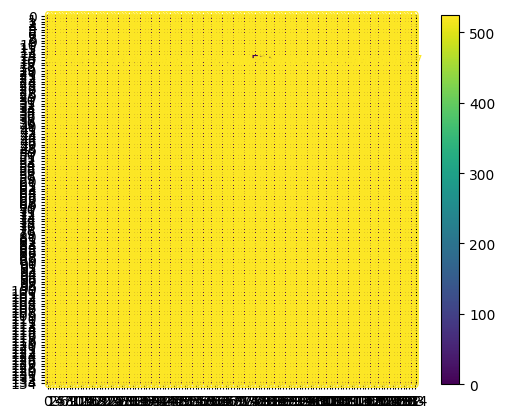

In [1695]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

#convert y values to categorical values
lab = preprocessing.LabelEncoder()
y_transformed1 = lab.fit_transform(y_test)


confusion_matrix = metrics.confusion_matrix(clf, y_transformed1)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['hibiscus', 'daffodil' ,'lily' ])

cm_display.plot()
plt.show()